# QPIE Phase 7 — PathMNIST
## Quantum encoding of H&E-stained colon pathology images

PathMNIST: 9-class colon tissue classification (28×28 RGB, ~90K train).  
H&E staining: hematoxylin (blue/purple = nuclei) vs eosin (pink = cytoplasm).  
Tissue types are distinguished primarily by **colour channel ratios** —
exactly what quantum encoding of R/G/B channels should capture.


Train: (89996, 28, 28, 3), Test: (7180, 28, 28, 3)
Classes: 9 — ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Train dist: [ 9366  9509 10360 10401  8006 12182  7886  9401 12885]

Global channel correlations:
  ρ(R,G) = 0.892
  ρ(G,B) = 0.966
  ρ(R,B) = 0.928


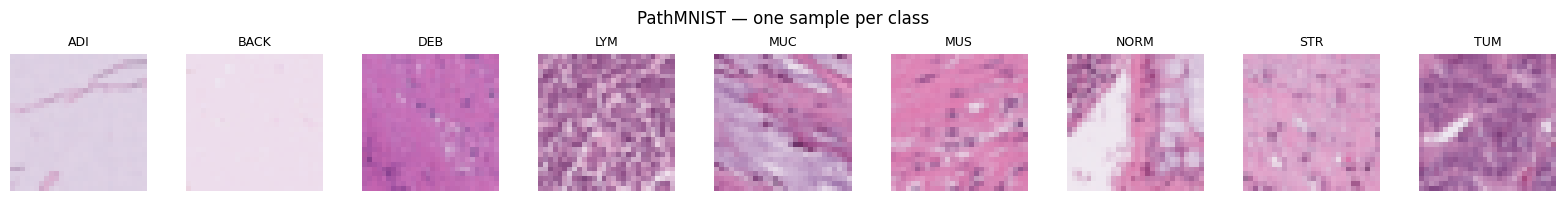

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PathMNIST
import time, warnings
warnings.filterwarnings('ignore')

train_ds = PathMNIST(split='train', download=True, size=28)
test_ds  = PathMNIST(split='test',  download=True, size=28)

X_train = train_ds.imgs
y_train = train_ds.labels.ravel()
X_test  = test_ds.imgs
y_test  = test_ds.labels.ravel()

class_names = ['ADI','BACK','DEB','LYM','MUC','MUS','NORM','STR','TUM']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {len(np.unique(y_train))} — {class_names}")
print(f"Train dist: {np.bincount(y_train)}")

flat = X_train.reshape(-1, 3).astype(float)
C = np.corrcoef(flat.T)
print(f"\nGlobal channel correlations:")
print(f"  ρ(R,G) = {C[0,1]:.3f}")
print(f"  ρ(G,B) = {C[1,2]:.3f}")
print(f"  ρ(R,B) = {C[0,2]:.3f}")

# Show one sample per class
fig, axes = plt.subplots(1, 9, figsize=(16, 2))
for cls in range(9):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].imshow(X_train[idx])
    axes[cls].set_title(class_names[cls], fontsize=9)
    axes[cls].axis('off')
plt.suptitle('PathMNIST — one sample per class', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# ==================================================================
# Encoding functions + multi-basis measurement
# ==================================================================

def _theta(rgb):
    return rgb.astype(np.float64) / 255.0 * (np.pi / 2)

def _amps_sep(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([cR*cG*cB, sR*cG*cB, cR*sG*cB, sR*sG*cB,
                            cR*cG*sB, sR*cG*sB, cR*sG*sB, sR*sG*sB])

def _amps_crye(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([ cR*cG*cB, -sR*sG*cB, -cR*sG*sB, -sR*cG*sB,
                             cR*cG*sB, -sR*sG*sB,  cR*sG*cB,  sR*cG*cB])

def _amps_gbe(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([
        cR*cG*cB-sR*sG*sB, sR*cG*cB+cR*sG*sB, cR*sG*cB+sR*cG*sB, sR*sG*cB-cR*cG*sB,
        cR*cG*sB+sR*sG*cB, sR*cG*sB-cR*sG*cB, cR*sG*sB-sR*cG*cB, sR*sG*sB+cR*cG*cB
    ]) / np.sqrt(2)

def _amps_pa_cse(rgb):
    t = _theta(rgb)
    cR,sR = np.cos(t[:,0]), np.sin(t[:,0])
    cG,sG = np.cos(t[:,1]), np.sin(t[:,1])
    cB,sB = np.cos(t[:,2]), np.sin(t[:,2])
    norm = rgb.astype(np.float64) / 255.0
    a_rg = norm[:,0] * norm[:,1] * np.pi / 2
    a_gb = norm[:,1] * norm[:,2] * np.pi / 2
    cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
    cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
    return np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                            cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])

# --- Statevector simulation primitives ---
def apply_ry(state, theta, q):
    c = np.cos(theta/2); s = np.sin(theta/2)
    new = state.copy(); stride = 1 << q
    for a in range(8):
        if a & stride == 0:
            b = a + stride
            new[:, a] = c * state[:, a] - s * state[:, b]
            new[:, b] = s * state[:, a] + c * state[:, b]
    return new

def apply_crz(state, alpha, ctrl, tgt):
    new = state.copy(); cs, ts = 1 << ctrl, 1 << tgt
    p_neg, p_pos = np.exp(-1j * alpha / 2), np.exp(1j * alpha / 2)
    for idx in range(8):
        if idx & cs:
            new[:, idx] = (p_pos if idx & ts else p_neg) * state[:, idx]
    return new

def init_state(N):
    s = np.zeros((N, 8), dtype=complex); s[:, 0] = 1.0; return s

# --- CP-2L: 2-layer controlled-phase with data re-uploading ---
def _amps_cp_2L(rgb):
    t = _theta(rgb); N = len(t); s = init_state(N)
    for layer, perm in enumerate([(0,1,2), (2,0,1)]):
        s = apply_ry(s, t[:,perm[0]], 0)
        s = apply_ry(s, t[:,perm[1]], 1)
        s = apply_ry(s, t[:,perm[2]], 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[1]], 0, 1)
        s = apply_crz(s, t[:,perm[1]]*t[:,perm[2]], 1, 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[2]], 0, 2)
    return s

# --- CP-3L: 3-layer controlled-phase — full permutation cycle ---
# More expressivity: cycles through all 3 channel orderings (RGB, BRG, GBR)
def _amps_cp_3L(rgb):
    t = _theta(rgb); N = len(t); s = init_state(N)
    for layer, perm in enumerate([(0,1,2), (2,0,1), (1,2,0)]):
        s = apply_ry(s, t[:,perm[0]], 0)
        s = apply_ry(s, t[:,perm[1]], 1)
        s = apply_ry(s, t[:,perm[2]], 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[1]], 0, 1)
        s = apply_crz(s, t[:,perm[1]]*t[:,perm[2]], 1, 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[2]], 0, 2)
    return s

# --- Multi-basis measurement machinery ---
_H = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)
_HSd = np.array([[1,-1j],[1,1j]], dtype=complex) / np.sqrt(2)
def _kron_n(M, n):
    R = M
    for _ in range(n-1): R = np.kron(R, M)
    return R
_V = {3: [np.eye(8,dtype=complex), _kron_n(_H,3), _kron_n(_HSd,3)]}

def multi_basis(amps, nq=3):
    return np.hstack([np.abs(amps @ V.T)**2 for V in _V[nq]])

In [7]:
# ==================================================================
# AGGREGATED features + Optimised classification
# Memory-safe: extract ONE scheme → aggregate → train → delete → next.
# Enriched aggregation: mean, std, skew, kurtosis, percentiles (p10-p90)
# Optimised MLP: 512→256→128, 200 epochs, cosine annealing
# HARDWARE-OPTIMISED for M4 MPS GPU
# ==================================================================
import torch, torch.nn as nn, gc
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import balanced_accuracy_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.kernel_approximation import RBFSampler
from scipy.stats import ttest_rel

N_tr, N_te = len(X_train), len(X_test)
n_classes = len(class_names)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")
N_SEEDS = 5
NPIX = 784

# --- Fast aggregation (pure numpy, no scipy) ---
def agg(X_flat, npix=NPIX):
    """Statistical aggregation — pure numpy for speed."""
    N = len(X_flat); d = X_flat.shape[1] // npix
    P = X_flat.reshape(N, npix, d)
    mu  = P.mean(1)
    std = P.std(1) + 1e-10
    # Fast skew & kurtosis (avoids slow scipy)
    P_c = P - mu[:, None, :]
    sk = (P_c**3).mean(1) / (std**3)
    ku = (P_c**4).mean(1) / (std**4) - 3.0
    # All percentiles in one call
    pcts = np.percentile(P, [10, 25, 50, 75, 90], axis=1)  # (5, N, d)
    # Inter-component correlations
    norms = np.sqrt((P_c**2).sum(1, keepdims=True) + 1e-10)
    P_n = P_c / norms
    C = np.einsum('npi,npj->nij', P_n, P_n) / npix
    ii, jj = np.triu_indices(d, k=1)
    corr = C[:, ii, jj]
    return np.nan_to_num(np.hstack([
        mu, std, sk, ku,
        pcts[0], pcts[1], pcts[2], pcts[3], pcts[4],
        corr
    ]).astype(np.float32))

# --- Batched extract + aggregate ---
def _ext_and_agg(X, fn, nq, mb, batch_size=10000):
    N = len(X); results = []
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        a = fn(X[start:end].reshape(-1, 3))
        f = multi_basis(a, nq) if mb else np.abs(a)**2
        raw = f.reshape(end - start, -1).astype(np.float32)
        results.append(agg(raw))
        del a, f, raw
    return np.vstack(results)

# --- Vectorised CSE (no per-image loop!) ---
def _ext_cse_agg_vec(X, mb, batch_size=10000):
    """CSE with vectorised per-image correlation computation."""
    N = len(X); results = []
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        batch = X[start:end]  # (B, 28, 28, 3)
        B = end - start
        px = batch.reshape(B, NPIX, 3).astype(np.float64)
        # Vectorised per-image correlation: (B, 3, 3)
        mu_px = px.mean(1, keepdims=True)              # (B, 1, 3)
        centered = px - mu_px                            # (B, 784, 3)
        cov = np.einsum('npi,npj->nij', centered, centered) / (NPIX - 1)  # (B, 3, 3)
        std_px = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)      # (B, 3)
        outer_std = std_px[:, :, None] * std_px[:, None, :]                # (B, 3, 3)
        corr_mat = cov / (outer_std + 1e-10)
        rg = np.clip(np.abs(corr_mat[:, 0, 1]), 0.01, 0.99)  # (B,)
        gb = np.clip(np.abs(corr_mat[:, 1, 2]), 0.01, 0.99)  # (B,)
        # Now encode all pixels for entire batch
        px_flat = px.reshape(-1, 3)  # (B*784, 3)
        t = _theta(px_flat)
        cR, sR = np.cos(t[:,0]), np.sin(t[:,0])
        cG, sG = np.cos(t[:,1]), np.sin(t[:,1])
        cB, sB = np.cos(t[:,2]), np.sin(t[:,2])
        # Repeat per-image correlations for each pixel
        a_rg = np.repeat(rg, NPIX) * np.pi / 2  # (B*784,)
        a_gb = np.repeat(gb, NPIX) * np.pi / 2
        cGe, sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
        cBe, sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
        amps = np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                                cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])
        f = multi_basis(amps, 3) if mb else np.abs(amps)**2
        raw = f.reshape(B, -1).astype(np.float32)
        results.append(agg(raw))
        del px, centered, cov, amps, f, raw
    return np.vstack(results)

# --- Optimised PyTorch GPU MLP ---
def train_gpu(Xtr, ytr, Xte, yte, seed, epochs=200):
    torch.manual_seed(seed); np.random.seed(seed)
    d = Xtr.shape[1]; nc = len(np.unique(ytr))
    mu, std = Xtr.mean(0), Xtr.std(0) + 1e-8
    Xtr_n = torch.tensor((Xtr - mu) / std, dtype=torch.float32)
    Xte_n = torch.tensor((Xte - mu) / std, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    loader = DataLoader(TensorDataset(Xtr_n, ytr_t),
                        batch_size=512, shuffle=True,
                        num_workers=0, pin_memory=False)  # MPS: workers=0 is fastest
    model = nn.Sequential(
        nn.Linear(d, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.3),
        nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.2),
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.1),
        nn.Linear(128, nc)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss_fn(model(xb), yb).backward()
            opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        Xt = Xte_n.to(device)
        logits = model(Xt)
        pred = logits.argmax(1).cpu().numpy()
        probs = torch.softmax(logits, 1).cpu().numpy()
    del model, loader, Xt, logits, Xtr_n, Xte_n, ytr_t
    torch.mps.empty_cache() if hasattr(torch.mps, 'empty_cache') else None
    return pred, probs

# --- Scheme configs ---
configs = [
    ('Raw RGB',           None,          3, False),
    ('Sep (Z)',           _amps_sep,     3, False),
    ('Sep (Z+X+Y)',       _amps_sep,    3, True),
    ('CRyE (Z+X+Y)',       _amps_crye,    3, True),
    ('GBE (Z+X+Y)',    _amps_gbe,   3, True),
    ('CSE (Z+X+Y)',       'cse',        3, True),
    ('PA-CSE (Z+X+Y)',    _amps_pa_cse, 3, True),
    ('CP-2L (Z+X+Y)',     _amps_cp_2L,  3, True),
    ('CP-3L (Z+X+Y)',     _amps_cp_3L,  3, True),
    ('RBF-24 (classical)', 'rbf',       3, True),
]

y_te_bin = label_binarize(y_test, classes=np.arange(n_classes))

print(f"\nSOTA ref: ResNet-18(28) ACC≈0.909  AUC≈0.989")
print(f"Enriched aggregation + Optimised MLP (512→256→128, 200ep, {N_SEEDS} seeds)")
print()
print(f"{'Scheme':25s}  {'ACC':>8s} {'±':>6s}  {'BA':>8s} {'±':>6s}  {'AUC':>8s} {'±':>6s}  {'dim':>4s}")
print("=" * 95)

summary = {}
all_accs = {}
t_total = time.time()

for name, fn, nq, mb in configs:
    t0 = time.time()

    # --- Extract + aggregate ---
    if fn is None:  # Raw RGB
        Atr = agg(X_train.reshape(N_tr, -1).astype(np.float32) / 255.0, npix=NPIX)
        Ate = agg(X_test.reshape(N_te, -1).astype(np.float32) / 255.0, npix=NPIX)
    elif fn == 'rbf':
        rbf24 = RBFSampler(n_components=24, gamma=1.0, random_state=42)
        px_tr = X_train.reshape(-1, 3).astype(np.float32) / 255.0
        px_te = X_test.reshape(-1, 3).astype(np.float32) / 255.0
        rbf24.fit(px_tr)
        Atr = agg(rbf24.transform(px_tr).reshape(N_tr, -1).astype(np.float32))
        Ate = agg(rbf24.transform(px_te).reshape(N_te, -1).astype(np.float32))
        del px_tr, px_te, rbf24
    elif fn == 'cse':
        Atr = _ext_cse_agg_vec(X_train, mb)
        Ate = _ext_cse_agg_vec(X_test, mb)
    else:
        Atr = _ext_and_agg(X_train, fn, nq, mb)
        Ate = _ext_and_agg(X_test, fn, nq, mb)

    ext_time = time.time() - t0

    # --- Train & evaluate ---
    accs, bas, aucs = [], [], []
    for seed in range(N_SEEDS):
        pred, probs = train_gpu(Atr, y_train, Ate, y_test, seed=seed)
        accs.append(accuracy_score(y_test, pred))
        bas.append(balanced_accuracy_score(y_test, pred))
        aucs.append(roc_auc_score(y_te_bin, probs, multi_class='ovr', average='macro'))

    d = Atr.shape[1]
    summary[name] = dict(acc=np.mean(accs), acc_s=np.std(accs),
                         ba=np.mean(bas), ba_s=np.std(bas),
                         auc=np.mean(aucs), auc_s=np.std(aucs), d=d)
    all_accs[name] = accs
    tag = " ← CLS" if "classical" in name or "Raw" in name else ""
    print(f"{name:25s}  {np.mean(accs):.4f} ±{np.std(accs):.4f}  "
          f"{np.mean(bas):.4f} ±{np.std(bas):.4f}  "
          f"{np.mean(aucs):.4f} ±{np.std(aucs):.4f}  {d:>4d}  "
          f"(ext:{ext_time:.0f}s total:{time.time()-t0:.0f}s){tag}")

    # --- Free memory ---
    del Atr, Ate; gc.collect()

print(f"\nTotal: {time.time()-t_total:.0f}s")

# Rankings
print("\nRANKING BY ACC:")
for i, (n, v) in enumerate(sorted(summary.items(), key=lambda x: -x[1]['acc'])):
    tag = " ← CLASSICAL" if "classical" in n or "Raw" in n else ""
    gap = 0.909 - v['acc']
    print(f"  {i+1}. {n:25s}  ACC={v['acc']:.4f}  BA={v['ba']:.4f}  AUC={v['auc']:.4f}  "
          f"d={v['d']}  gap={gap:+.4f}{tag}")

# Fair comparison at equal agg dimensions
print("\nFAIR COMPARISON (equal agg features):")
for target_d in sorted(set(v['d'] for v in summary.values())):
    fair = {k: v for k, v in summary.items() if v['d'] == target_d}
    if len(fair) > 1:
        print(f"\n  --- {target_d} features ---")
        for n, v in sorted(fair.items(), key=lambda x: -x[1]['acc']):
            tag = " ← CLASSICAL" if "classical" in n else ""
            print(f"  {n:25s}  ACC={v['acc']:.4f} ± {v['acc_s']:.4f}{tag}")

# Paired t-tests vs Sep(Z+X+Y)
print("\nPAIRED T-TESTS vs Sep(Z+X+Y):")
ref = 'Sep (Z+X+Y)'
if ref in all_accs:
    for name in sorted(all_accs.keys()):
        if name == ref: continue
        diff = np.array(all_accs[name]) - np.array(all_accs[ref])
        t_stat, p_val = ttest_rel(all_accs[name], all_accs[ref])
        print(f"  {name:25s}  diff={np.mean(diff):+.4f}  p={p_val:.4f}  {'*' if p_val < 0.05 else ''}")

Device: mps

SOTA ref: ResNet-18(28) ACC≈0.909  AUC≈0.989
Enriched aggregation + Optimised MLP (512→256→128, 200ep, 5 seeds)

Scheme                          ACC      ±        BA      ±       AUC      ±   dim
Raw RGB                    0.5343 ±0.3248  0.5043 ±0.3211  0.7767 ±0.2259    30  (ext:10s total:469s) ← CLS
Sep (Z)                    0.8109 ±0.0044  0.7695 ±0.0047  0.9613 ±0.0010   100  (ext:26s total:486s)
Sep (Z+X+Y)                0.7966 ±0.0052  0.7593 ±0.0051  0.9581 ±0.0015   492  (ext:74s total:575s)
CRyE (Z+X+Y)               0.8089 ±0.0034  0.7681 ±0.0031  0.9614 ±0.0021   492  (ext:69s total:549s)
GBE (Z+X+Y)                0.6703 ±0.2493  0.6248 ±0.2569  0.8661 ±0.1831   492  (ext:73s total:616s)
CSE (Z+X+Y)                0.8130 ±0.0027  0.7664 ±0.0030  0.9659 ±0.0041   492  (ext:81s total:609s)
PA-CSE (Z+X+Y)             0.7828 ±0.0051  0.7459 ±0.0062  0.9618 ±0.0039   492  (ext:83s total:586s)
CP-2L (Z+X+Y)              0.8018 ±0.0042  0.7579 ±0.0053  0.9609 ±0.00

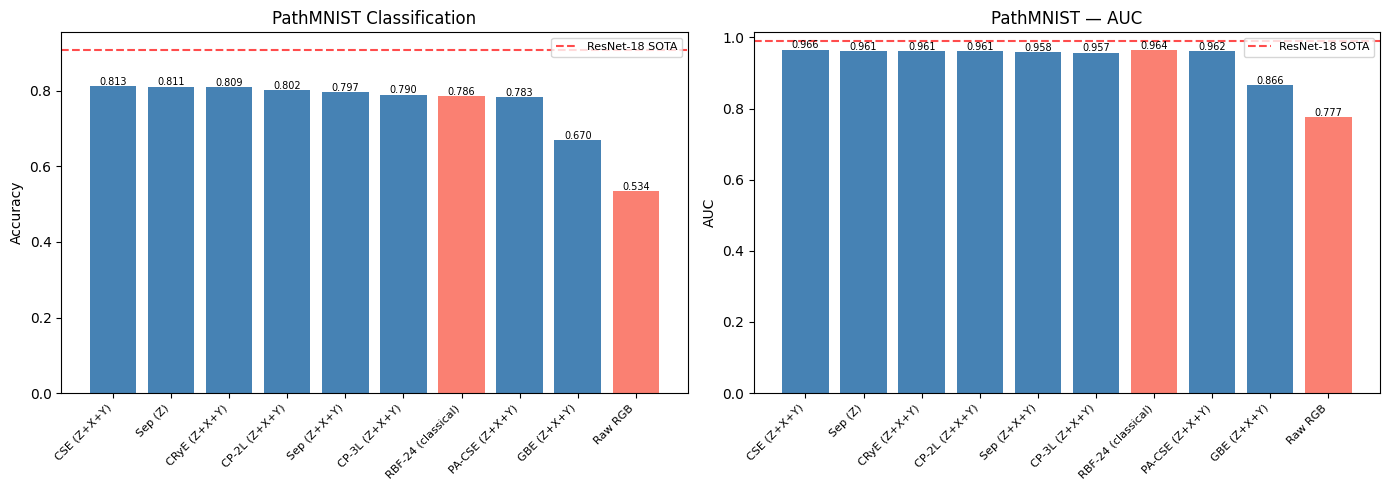

In [8]:
# ==================================================================
# Visualization
# ==================================================================
scheme_order = [n for n, _ in sorted(summary.items(), key=lambda x: -x[1]['acc'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['salmon' if 'classical' in s or 'Raw' in s else 'steelblue' for s in scheme_order]

accs = [summary[s]['acc'] for s in scheme_order]
bars = axes[0].bar(range(len(scheme_order)), accs, color=colors)
axes[0].set_xticks(range(len(scheme_order)))
axes[0].set_xticklabels(scheme_order, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('PathMNIST Classification')
axes[0].axhline(y=0.909, color='red', linestyle='--', alpha=0.7, label='ResNet-18 SOTA')
axes[0].legend(fontsize=8)
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=7)

aucs_v = [summary[s]['auc'] for s in scheme_order]
bars2 = axes[1].bar(range(len(scheme_order)), aucs_v, color=colors)
axes[1].set_xticks(range(len(scheme_order)))
axes[1].set_xticklabels(scheme_order, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('AUC')
axes[1].set_title('PathMNIST — AUC')
axes[1].axhline(y=0.989, color='red', linestyle='--', alpha=0.7, label='ResNet-18 SOTA')
axes[1].legend(fontsize=8)
for bar, v in zip(bars2, aucs_v):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

Class     ρ_RG    ρ_GB    ρ_RB    mean
ADI      0.957   0.993   0.973   0.974
BACK     0.570   0.895   0.590   0.685
DEB      0.832   0.974   0.852   0.886
LYM      0.974   0.997   0.983   0.984
MUC      0.937   0.991   0.945   0.958
MUS      0.800   0.975   0.847   0.874
NORM     0.940   0.994   0.952   0.962
STR      0.789   0.981   0.853   0.874
TUM      0.931   0.994   0.949   0.958
Extracting Sep...
  Sep per-class ACC: [0.836 1.    0.783 0.934 0.78  0.572 0.669 0.416 0.904]
Extracting CSE...
  CSE per-class ACC: [0.924 1.    0.769 0.934 0.789 0.493 0.692 0.385 0.894]

Pearson(class ρ, CSE-Sep gain) = +0.329  p = 0.388


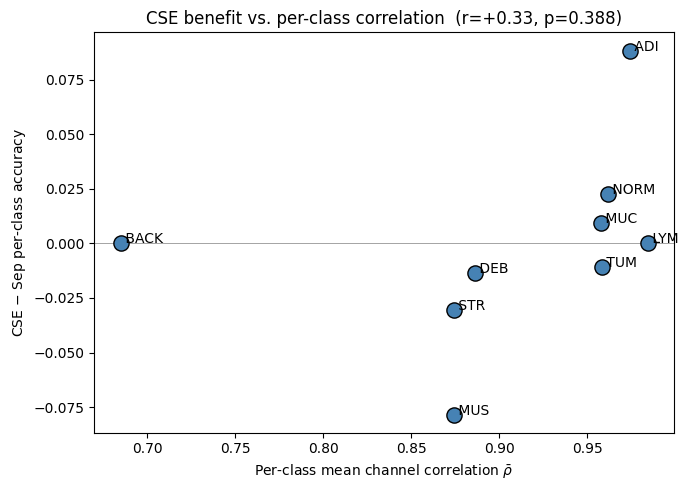

In [9]:
# ==================================================================
# Per-class correlation stratification
# Tests hypothesis: CSE advantage over Sep scales with per-class channel ρ
# ==================================================================
from scipy.stats import pearsonr

# 1. Per-image channel correlations (vectorised)
px_tr = X_train.reshape(N_tr, NPIX, 3).astype(np.float64)
cen = px_tr - px_tr.mean(1, keepdims=True)
cov = np.einsum('npi,npj->nij', cen, cen) / (NPIX - 1)
std = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)
rho = cov / (std[:,:,None] * std[:,None,:] + 1e-10)
rho_rg, rho_gb, rho_rb = rho[:,0,1], rho[:,1,2], rho[:,0,2]

class_rho_triplet = np.zeros((n_classes, 3))
class_rho = np.zeros(n_classes)
print(f"{'Class':<6s} {'ρ_RG':>7s} {'ρ_GB':>7s} {'ρ_RB':>7s} {'mean':>7s}")
for k in range(n_classes):
    m = (y_train == k)
    class_rho_triplet[k] = [rho_rg[m].mean(), rho_gb[m].mean(), rho_rb[m].mean()]
    class_rho[k] = class_rho_triplet[k].mean()
    print(f"{class_names[k]:<6s} {class_rho_triplet[k,0]:>7.3f} {class_rho_triplet[k,1]:>7.3f} {class_rho_triplet[k,2]:>7.3f} {class_rho[k]:>7.3f}")

del px_tr, cen, cov, std, rho; gc.collect()

# 2. Per-class accuracy for Sep and CSE (matched seeds, matched MLP)
per_class_acc = {}
for name, extract in [('Sep', lambda X: _ext_and_agg(X, _amps_sep, 3, True)),
                      ('CSE', lambda X: _ext_cse_agg_vec(X, True))]:
    print(f'Extracting {name}...')
    Atr, Ate = extract(X_train), extract(X_test)
    per_seed = np.zeros((N_SEEDS, n_classes))
    for seed in range(N_SEEDS):
        pred, _ = train_gpu(Atr, y_train, Ate, y_test, seed=seed)
        for k in range(n_classes):
            mk = (y_test == k)
            per_seed[seed, k] = (pred[mk] == k).mean()
    per_class_acc[name] = per_seed.mean(0)
    print(f'  {name} per-class ACC: {np.round(per_class_acc[name], 3)}')
    del Atr, Ate; gc.collect()

gains = per_class_acc['CSE'] - per_class_acc['Sep']
r, p = pearsonr(class_rho, gains)
print(f"\nPearson(class ρ, CSE-Sep gain) = {r:+.3f}  p = {p:.3f}")

# 3. Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(class_rho, gains, s=120, color='steelblue', edgecolors='black', zorder=3)
for i, n in enumerate(class_names):
    ax.annotate(f' {n}', (class_rho[i], gains[i]), fontsize=10)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Per-class mean channel correlation $\\bar\\rho$')
ax.set_ylabel('CSE $-$ Sep per-class accuracy')
ax.set_title(f'CSE benefit vs. per-class correlation  (r={r:+.2f}, p={p:.3f})')
plt.tight_layout()
plt.savefig('paper/figures/fig_stratification.png', dpi=150, bbox_inches='tight')
plt.savefig('paper/figures/fig_stratification.pdf', bbox_inches='tight')
plt.show()


Per-image ρ: min=0.335  median=0.970  max=0.997  std=0.112
Extracting Sep...
  Sep mean ACC: 0.7984
Extracting CSE...
  CSE mean ACC: 0.8124
Extracting CRyE...
  CRyE mean ACC: 0.8096
Extracting CP-2L...
  CP-2L mean ACC: 0.8045

QUINTILE WIN-RATE ANALYSIS

CSE vs Sep — gap by ρ quintile:
  Q1 [0.335, 0.903]  N=1436  Sep=0.7718  CSE=0.7628  gap=-0.0091
  Q2 [0.903, 0.960]  N=1436  Sep=0.7474  CSE=0.7205  gap=-0.0269
  Q3 [0.960, 0.976]  N=1436  Sep=0.7614  CSE=0.8048  gap=+0.0434
  Q4 [0.976, 0.984]  N=1436  Sep=0.8354  CSE=0.8858  gap=+0.0504
  Q5 [0.984, 0.997]  N=1436  Sep=0.8758  CSE=0.8883  gap=+0.0125
  Spearman(ρ_img, gap) = +0.0584  p = 0.0000

CRyE vs Sep — gap by ρ quintile:
  Q1 [0.335, 0.903]  N=1436  Sep=0.7718  CRyE=0.7702  gap=-0.0016
  Q2 [0.903, 0.960]  N=1436  Sep=0.7474  CRyE=0.7349  gap=-0.0125
  Q3 [0.960, 0.976]  N=1436  Sep=0.7614  CRyE=0.7925  gap=+0.0311
  Q4 [0.976, 0.984]  N=1436  Sep=0.8354  CRyE=0.8672  gap=+0.0318
  Q5 [0.984, 0.997]  N=1436  Sep=0.8758  C

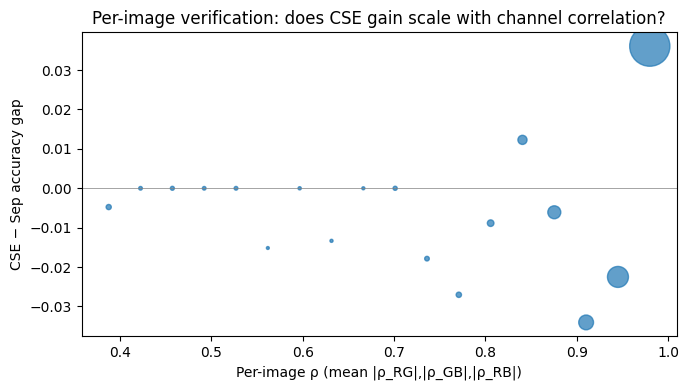


Saved: paper/figures/fig_per_image_rho.{png,pdf}


In [10]:
# ==================================================================
# Per-image ρ vs scheme accuracy — lightweight verification
# Hypothesis: if a scheme truly leverages entanglement driven by channel
# correlation, high-ρ images should show larger gains over Sep than low-ρ.
# Tests: (1) quintile win-rate, (2) logistic regression, (3) disagreement subset.
# Cost: re-trains 4 schemes × 3 seeds on existing extractions (~5-10 min).
# ==================================================================
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression

N_SEEDS_VER = 3

# --- Per-image ρ on TEST set ---
px_te = X_test.reshape(N_te, NPIX, 3).astype(np.float64)
cen = px_te - px_te.mean(1, keepdims=True)
cov = np.einsum('npi,npj->nij', cen, cen) / (NPIX - 1)
std = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)
rho_mat = cov / (std[:,:,None] * std[:,None,:] + 1e-10)
rho_img = np.mean(np.abs(np.stack([rho_mat[:,0,1], rho_mat[:,1,2], rho_mat[:,0,2]], axis=1)), axis=1)
del px_te, cen, cov, std, rho_mat; gc.collect()
print(f"Per-image ρ: min={rho_img.min():.3f}  median={np.median(rho_img):.3f}  max={rho_img.max():.3f}  std={rho_img.std():.3f}")

# --- Schemes to verify ---
schemes_ver = [
    ('Sep',   lambda X: _ext_and_agg(X, _amps_sep,    3, True)),
    ('CSE',   lambda X: _ext_cse_agg_vec(X, True)),
    ('CRyE',  lambda X: _ext_and_agg(X, _amps_crye,   3, True)),
    ('CP-2L', lambda X: _ext_and_agg(X, _amps_cp_2L,  3, True)),
]

# --- Correctness matrices: (N_SEEDS_VER, N_te) ∈ {0,1} ---
correct = {}
for name, extract in schemes_ver:
    print(f"Extracting {name}...")
    Atr, Ate = extract(X_train), extract(X_test)
    C = np.zeros((N_SEEDS_VER, N_te), dtype=np.int8)
    for s in range(N_SEEDS_VER):
        pred, _ = train_gpu(Atr, y_train, Ate, y_test, seed=s)
        C[s] = (pred == y_test).astype(np.int8)
    correct[name] = C
    del Atr, Ate; gc.collect()
    print(f"  {name} mean ACC: {C.mean():.4f}")

# --- Analysis: Sep vs each entangling scheme ---
sep_correct = correct['Sep']  # (S, N)

print("\n" + "=" * 80)
print("QUINTILE WIN-RATE ANALYSIS")
print("=" * 80)
q_edges = np.quantile(rho_img, np.linspace(0, 1, 6))
q_idx = np.clip(np.digitize(rho_img, q_edges[1:-1]), 0, 4)

for scheme in ['CSE', 'CRyE', 'CP-2L']:
    sch_correct = correct[scheme]
    # Average correctness per image over seeds
    p_sch = sch_correct.mean(0); p_sep = sep_correct.mean(0)
    gap = p_sch - p_sep
    print(f"\n{scheme} vs Sep — gap by ρ quintile:")
    for q in range(5):
        mask = q_idx == q
        lo, hi = q_edges[q], q_edges[q+1]
        print(f"  Q{q+1} [{lo:.3f}, {hi:.3f}]  N={mask.sum():4d}  "
              f"Sep={p_sep[mask].mean():.4f}  {scheme}={p_sch[mask].mean():.4f}  "
              f"gap={gap[mask].mean():+.4f}")
    r, p = spearmanr(rho_img, gap)
    print(f"  Spearman(ρ_img, gap) = {r:+.4f}  p = {p:.4f}")

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION: P(scheme_correct | ρ, sep_correct)")
print("=" * 80)
# Pool over seeds: stack all (seed, img) pairs → N_SEEDS_VER * N_te samples
rho_pool = np.tile(rho_img, N_SEEDS_VER)
sep_pool = sep_correct.ravel()
for scheme in ['CSE', 'CRyE', 'CP-2L']:
    y_pool = correct[scheme].ravel()
    X_pool = np.column_stack([rho_pool, sep_pool])
    lr = LogisticRegression(max_iter=500).fit(X_pool, y_pool)
    beta_rho, beta_sep = lr.coef_[0]
    print(f"{scheme:>6s}:  β_ρ = {beta_rho:+.4f}   β_sep = {beta_sep:+.4f}   "
          f"(β_ρ > 0 ⇒ higher ρ → more likely correct, controlling for Sep)")

print("\n" + "=" * 80)
print("DISAGREEMENT SUBSET: when Sep and scheme disagree, who wins more at high ρ?")
print("=" * 80)
for scheme in ['CSE', 'CRyE', 'CP-2L']:
    sch_correct = correct[scheme]
    # Per-seed disagreement analysis, then pool
    wins_hi, wins_lo, n_hi, n_lo = 0, 0, 0, 0
    med = np.median(rho_img)
    for s in range(N_SEEDS_VER):
        disagree = sch_correct[s] != sep_correct[s]
        hi = disagree & (rho_img >= med)
        lo = disagree & (rho_img <  med)
        wins_hi += sch_correct[s][hi].sum(); n_hi += hi.sum()
        wins_lo += sch_correct[s][lo].sum(); n_lo += lo.sum()
    print(f"{scheme:>6s}:  high-ρ disagreement {scheme}-wins = {wins_hi}/{n_hi} = {wins_hi/max(n_hi,1):.3f}   "
          f"low-ρ = {wins_lo}/{n_lo} = {wins_lo/max(n_lo,1):.3f}")

# --- Scatter plot: ρ_img vs (CSE - Sep) gap ---
fig, ax = plt.subplots(figsize=(7, 4))
p_cse = correct['CSE'].mean(0); p_sep_avg = sep_correct.mean(0)
bins = np.linspace(rho_img.min(), rho_img.max(), 20)
bin_idx = np.digitize(rho_img, bins)
bin_centers, bin_gaps, bin_ns = [], [], []
for b in range(1, len(bins)):
    m = bin_idx == b
    if m.sum() >= 20:
        bin_centers.append((bins[b-1]+bins[b])/2)
        bin_gaps.append((p_cse[m] - p_sep_avg[m]).mean())
        bin_ns.append(m.sum())
ax.scatter(bin_centers, bin_gaps, s=np.array(bin_ns)/5, alpha=0.7)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Per-image ρ (mean |ρ_RG|,|ρ_GB|,|ρ_RB|)')
ax.set_ylabel('CSE − Sep accuracy gap')
ax.set_title('Per-image verification: does CSE gain scale with channel correlation?')
plt.tight_layout()
plt.savefig('paper/figures/fig_per_image_rho.png', dpi=150, bbox_inches='tight')
plt.savefig('paper/figures/fig_per_image_rho.pdf', bbox_inches='tight')
plt.show()
print("\nSaved: paper/figures/fig_per_image_rho.{png,pdf}")


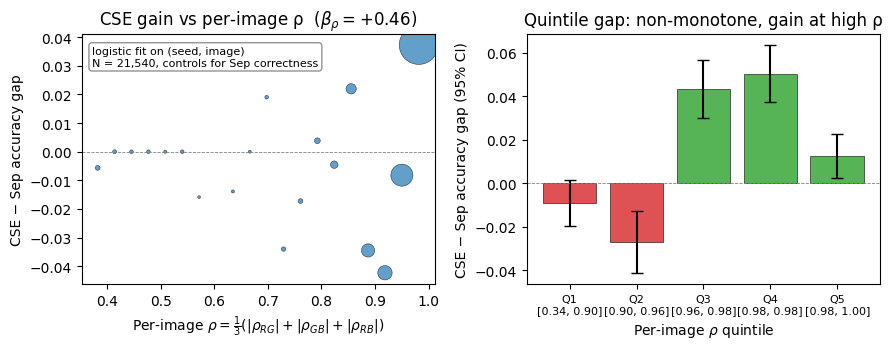


Saved: paper/figures/fig_mechanism.{pdf,png}  (β_ρ = +0.4586)


In [16]:
# ==================================================================
# Manuscript figure: fig_mechanism.{pdf,png}
# Two panels:
#   (left)  per-image ρ vs CSE-vs-Sep correctness, logistic fit, β_ρ annotated
#   (right) 5-quintile bar plot of CSE − Sep accuracy gap with 95% CI
# Requires cell 6 to have been run (uses correct, rho_img, q_idx, sep_correct, N_SEEDS_VER).
# ==================================================================
import os
os.makedirs('paper/figures', exist_ok=True)

# --- Left panel data: pool over seeds, fit logistic with sep_correct as control
rho_pool = np.tile(rho_img, N_SEEDS_VER)
sep_pool = sep_correct.ravel()
y_cse    = correct['CSE'].ravel()
X_pool   = np.column_stack([rho_pool, sep_pool])
lr = LogisticRegression(max_iter=500).fit(X_pool, y_cse)
beta_rho_cse = lr.coef_[0, 0]

# Binned scatter (CSE-Sep gap by ρ) — same construction as the existing cell 6 plot
p_cse_img = correct['CSE'].mean(0)
p_sep_img = sep_correct.mean(0)
gap_img   = p_cse_img - p_sep_img
bins      = np.linspace(rho_img.min(), rho_img.max(), 22)
bin_idx   = np.digitize(rho_img, bins)
bin_x, bin_y, bin_n = [], [], []
for b in range(1, len(bins)):
    m = bin_idx == b
    if m.sum() >= 20:
        bin_x.append((bins[b-1] + bins[b]) / 2)
        bin_y.append(gap_img[m].mean())
        bin_n.append(m.sum())
bin_x, bin_y, bin_n = np.array(bin_x), np.array(bin_y), np.array(bin_n)

# --- Right panel data: quintile gap with 95% CI from per-image gap
quintile_means, quintile_lo, quintile_hi, quintile_labels = [], [], [], []
for q in range(5):
    m = q_idx == q
    g = gap_img[m]
    mu = g.mean()
    se = g.std(ddof=1) / np.sqrt(m.sum())
    quintile_means.append(mu)
    quintile_lo.append(mu - 1.96 * se)
    quintile_hi.append(mu + 1.96 * se)
    lo, hi = q_edges[q], q_edges[q + 1]
    quintile_labels.append(f'Q{q+1}\n[{lo:.2f}, {hi:.2f}]')

# --- Plot
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 3.6))

# Left: binned scatter + horizontal zero + β_ρ annotation
axL.scatter(bin_x, bin_y, s=bin_n / 5, alpha=0.7, color='#1f77b4', edgecolor='k', lw=0.4)
axL.axhline(0, color='gray', lw=0.6, linestyle='--')
axL.set_xlabel(r'Per-image $\rho = \frac{1}{3}(|\rho_{RG}| + |\rho_{GB}| + |\rho_{RB}|)$')
axL.set_ylabel('CSE − Sep accuracy gap')
axL.set_title(f'CSE gain vs per-image ρ  ($\\beta_\\rho = {beta_rho_cse:+.2f}$)')
axL.text(0.03, 0.95,
         f'logistic fit on (seed, image)\nN = {len(rho_pool):,}, controls for Sep correctness',
         transform=axL.transAxes, va='top', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

# Right: quintile bars with 95% CI
xpos = np.arange(5)
yerr = np.array([np.array(quintile_means) - np.array(quintile_lo),
                 np.array(quintile_hi) - np.array(quintile_means)])
colors = ['#d62728' if m < 0 else '#2ca02c' for m in quintile_means]
axR.bar(xpos, quintile_means, yerr=yerr, color=colors, alpha=0.8,
        edgecolor='k', lw=0.5, capsize=4)
axR.axhline(0, color='gray', lw=0.6, linestyle='--')
axR.set_xticks(xpos)
axR.set_xticklabels(quintile_labels, fontsize=8)
axR.set_xlabel(r'Per-image $\rho$ quintile')
axR.set_ylabel('CSE − Sep accuracy gap (95% CI)')
axR.set_title('Quintile gap: non-monotone, gain at high ρ')

plt.tight_layout()
plt.savefig('paper/figures/fig_mechanism.pdf', bbox_inches='tight')
plt.savefig('paper/figures/fig_mechanism.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: paper/figures/fig_mechanism.{{pdf,png}}  (β_ρ = {beta_rho_cse:+.4f})")


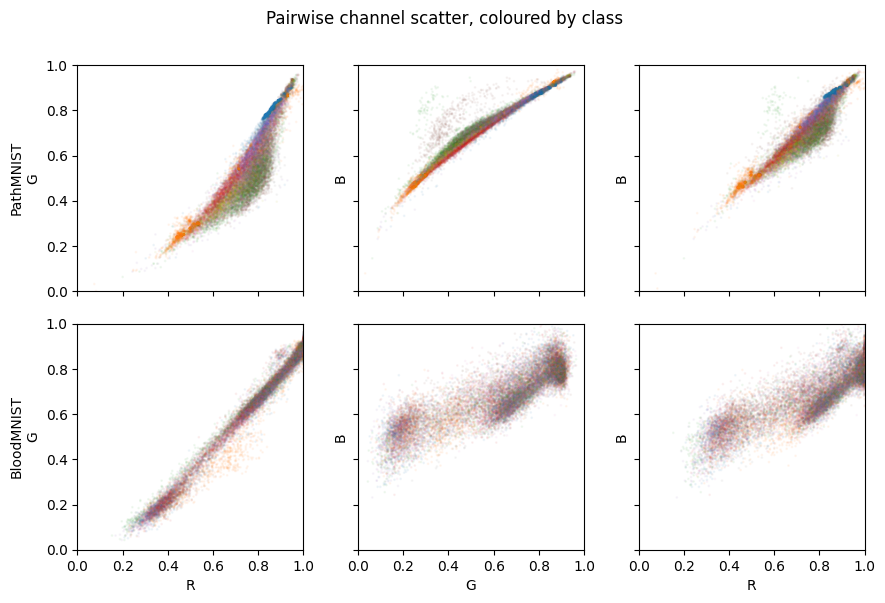

Saved: paper/figures/fig_channel_dep.{pdf,png}


In [17]:
# ==================================================================
# Manuscript figure: fig_channel_dep.{pdf,png}
# 2x3 grid of pairwise channel scatter plots, class-coloured.
# Top row: PathMNIST. Bottom row: BloodMNIST.
# Self-contained: loads both datasets fresh via medmnist.
# ==================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PathMNIST, BloodMNIST
os.makedirs('paper/figures', exist_ok=True)

def _load(cls, n_per_class=300, seed=0):
    ds = cls(split='train', download=True)
    X = ds.imgs.astype(np.float32) / 255.0   # (N, 28, 28, 3)
    y = ds.labels.ravel()
    rng = np.random.default_rng(seed)
    keep = []
    for c in np.unique(y):
        idx = np.flatnonzero(y == c)
        keep.append(rng.choice(idx, size=min(n_per_class, len(idx)), replace=False))
    keep = np.concatenate(keep)
    X, y = X[keep], y[keep]
    pix = X.reshape(-1, 3)               # (N*784, 3)
    lab = np.repeat(y, 28*28)
    return pix, lab, len(np.unique(y))

path_pix, path_lab, n_path = _load(PathMNIST)
blood_pix, blood_lab, n_blood = _load(BloodMNIST)

fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)
pairs = [(0, 1, 'R', 'G'), (1, 2, 'G', 'B'), (0, 2, 'R', 'B')]
cmap_path = plt.cm.tab10
cmap_blood = plt.cm.tab10

# Subsample pixels for plotting (RAM/render cost)
def _sub(pix, lab, n=20000, seed=0):
    rng = np.random.default_rng(seed)
    if len(pix) <= n: return pix, lab
    idx = rng.choice(len(pix), size=n, replace=False)
    return pix[idx], lab[idx]

path_pix_s, path_lab_s = _sub(path_pix, path_lab)
blood_pix_s, blood_lab_s = _sub(blood_pix, blood_lab)

for col, (i, j, ai, aj) in enumerate(pairs):
    axes[0, col].scatter(path_pix_s[:, i], path_pix_s[:, j],
                         c=cmap_path(path_lab_s % 10), s=1, alpha=0.05, rasterized=True)
    axes[1, col].scatter(blood_pix_s[:, i], blood_pix_s[:, j],
                         c=cmap_blood(blood_lab_s % 10), s=1, alpha=0.05, rasterized=True)
    axes[1, col].set_xlabel(ai)
    if col == 0:
        axes[0, col].set_ylabel(f'PathMNIST\n{aj}')
        axes[1, col].set_ylabel(f'BloodMNIST\n{aj}')
    else:
        axes[0, col].set_ylabel(aj)
        axes[1, col].set_ylabel(aj)
    axes[0, col].set_xlim(0, 1); axes[0, col].set_ylim(0, 1)
    axes[1, col].set_xlim(0, 1); axes[1, col].set_ylim(0, 1)
    axes[0, col].set_aspect('equal')
    axes[1, col].set_aspect('equal')

plt.suptitle('Pairwise channel scatter, coloured by class', y=1.00)
plt.tight_layout()
plt.savefig('paper/figures/fig_channel_dep.pdf', bbox_inches='tight')
plt.savefig('paper/figures/fig_channel_dep.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: paper/figures/fig_channel_dep.{pdf,png}')


Loading PathMNIST...
Loading BloodMNIST...


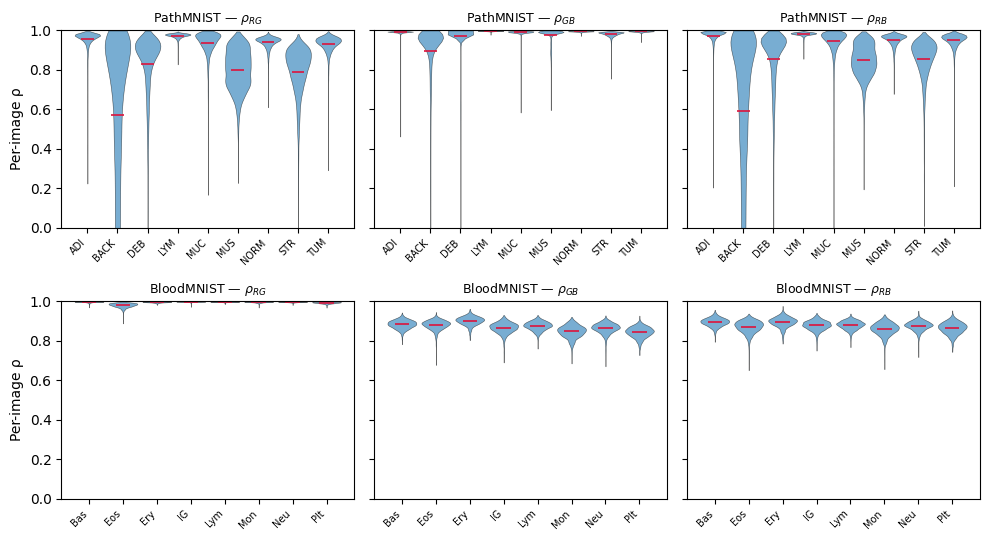

Saved: paper/figures/fig_corr_dist.{pdf,png}


In [14]:
# ==================================================================
# Manuscript figure: fig_corr_dist.{pdf,png}
# 2x3 violin plot: per-image ρ per class.
# Rows: PathMNIST (top), BloodMNIST (bottom).
# Cols: ρ_RG, ρ_GB, ρ_RB.
# Self-contained: loads both datasets fresh.
# ==================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PathMNIST, BloodMNIST
os.makedirs('paper/figures', exist_ok=True)

def _per_image_rho(cls):
    ds = cls(split='train', download=True)
    X = ds.imgs.astype(np.float32) / 255.0   # (N, 28, 28, 3)
    y = ds.labels.ravel()
    N = X.shape[0]
    pix = X.reshape(N, -1, 3)                 # (N, 784, 3)
    cen = pix - pix.mean(1, keepdims=True)
    cov = np.einsum('npi,npj->nij', cen, cen) / (pix.shape[1] - 1)
    std = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)
    rho = cov / (std[:, :, None] * std[:, None, :] + 1e-10)
    rho_rg = rho[:, 0, 1]
    rho_gb = rho[:, 1, 2]
    rho_rb = rho[:, 0, 2]
    return rho_rg, rho_gb, rho_rb, y

print('Loading PathMNIST...')
prg, pgb, prb, py = _per_image_rho(PathMNIST)
print('Loading BloodMNIST...')
brg, bgb, brb, by = _per_image_rho(BloodMNIST)

PATH_NAMES = ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
BLOOD_NAMES = ['Bas', 'Eos', 'Ery', 'IG', 'Lym', 'Mon', 'Neu', 'Plt']

def _violin(ax, data_per_class, names, title, ylim=(0, 1)):
    parts = ax.violinplot(data_per_class, positions=range(len(names)),
                          showmeans=True, showextrema=False, widths=0.85)
    for pc in parts['bodies']:
        pc.set_facecolor('#1f77b4')
        pc.set_alpha(0.6)
        pc.set_edgecolor('k')
        pc.set_linewidth(0.4)
    parts['cmeans'].set_color('crimson')
    parts['cmeans'].set_linewidth(1.2)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=9)
    ax.axhline(1.0, color='gray', lw=0.4, linestyle=':')

fig, axes = plt.subplots(2, 3, figsize=(10, 5.5), sharey=True)

for col, (rho_path, rho_blood, lbl) in enumerate([
        (prg, brg, r'$\rho_{RG}$'),
        (pgb, bgb, r'$\rho_{GB}$'),
        (prb, brb, r'$\rho_{RB}$')]):
    path_per_class = [rho_path[py == c] for c in range(len(PATH_NAMES))]
    blood_per_class = [rho_blood[by == c] for c in range(len(BLOOD_NAMES))]
    _violin(axes[0, col], path_per_class, PATH_NAMES, f'PathMNIST — {lbl}')
    _violin(axes[1, col], blood_per_class, BLOOD_NAMES, f'BloodMNIST — {lbl}')

axes[0, 0].set_ylabel('Per-image ρ')
axes[1, 0].set_ylabel('Per-image ρ')
plt.tight_layout()
plt.savefig('paper/figures/fig_corr_dist.pdf', bbox_inches='tight')
plt.savefig('paper/figures/fig_corr_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: paper/figures/fig_corr_dist.{pdf,png}')


In [ ]:
!brew install --cask mactex

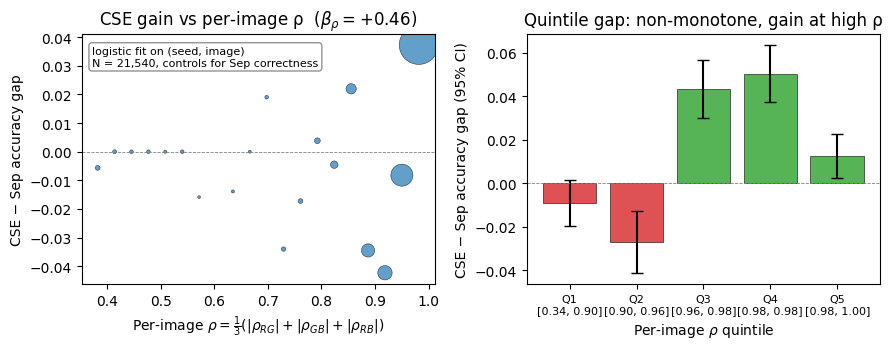


Saved: paper/figures/fig_mechanism.{pdf,png}  (β_ρ = +0.4586)


In [15]:
# ==================================================================
# Manuscript figure: fig_mechanism.{pdf,png}
# Two panels:
#   (left)  per-image ρ vs CSE-vs-Sep correctness, logistic fit, β_ρ annotated
#   (right) 5-quintile bar plot of CSE − Sep accuracy gap with 95% CI
# Requires cell 6 to have been run (uses correct, rho_img, q_idx, sep_correct, N_SEEDS_VER).
# ==================================================================
import os
os.makedirs('paper/figures', exist_ok=True)

# --- Left panel data: pool over seeds, fit logistic with sep_correct as control
rho_pool = np.tile(rho_img, N_SEEDS_VER)
sep_pool = sep_correct.ravel()
y_cse    = correct['CSE'].ravel()
X_pool   = np.column_stack([rho_pool, sep_pool])
lr = LogisticRegression(max_iter=500).fit(X_pool, y_cse)
beta_rho_cse = lr.coef_[0, 0]

# Binned scatter (CSE-Sep gap by ρ) — same construction as the existing cell 6 plot
p_cse_img = correct['CSE'].mean(0)
p_sep_img = sep_correct.mean(0)
gap_img   = p_cse_img - p_sep_img
bins      = np.linspace(rho_img.min(), rho_img.max(), 22)
bin_idx   = np.digitize(rho_img, bins)
bin_x, bin_y, bin_n = [], [], []
for b in range(1, len(bins)):
    m = bin_idx == b
    if m.sum() >= 20:
        bin_x.append((bins[b-1] + bins[b]) / 2)
        bin_y.append(gap_img[m].mean())
        bin_n.append(m.sum())
bin_x, bin_y, bin_n = np.array(bin_x), np.array(bin_y), np.array(bin_n)

# --- Right panel data: quintile gap with 95% CI from per-image gap
quintile_means, quintile_lo, quintile_hi, quintile_labels = [], [], [], []
for q in range(5):
    m = q_idx == q
    g = gap_img[m]
    mu = g.mean()
    se = g.std(ddof=1) / np.sqrt(m.sum())
    quintile_means.append(mu)
    quintile_lo.append(mu - 1.96 * se)
    quintile_hi.append(mu + 1.96 * se)
    lo, hi = q_edges[q], q_edges[q + 1]
    quintile_labels.append(f'Q{q+1}\n[{lo:.2f}, {hi:.2f}]')

# --- Plot
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 3.6))

# Left: binned scatter + horizontal zero + β_ρ annotation
axL.scatter(bin_x, bin_y, s=bin_n / 5, alpha=0.7, color='#1f77b4', edgecolor='k', lw=0.4)
axL.axhline(0, color='gray', lw=0.6, linestyle='--')
axL.set_xlabel(r'Per-image $\rho = \frac{1}{3}(|\rho_{RG}| + |\rho_{GB}| + |\rho_{RB}|)$')
axL.set_ylabel('CSE − Sep accuracy gap')
axL.set_title(f'CSE gain vs per-image ρ  ($\\beta_\\rho = {beta_rho_cse:+.2f}$)')
axL.text(0.03, 0.95,
         f'logistic fit on (seed, image)\nN = {len(rho_pool):,}, controls for Sep correctness',
         transform=axL.transAxes, va='top', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

# Right: quintile bars with 95% CI
xpos = np.arange(5)
yerr = np.array([np.array(quintile_means) - np.array(quintile_lo),
                 np.array(quintile_hi) - np.array(quintile_means)])
colors = ['#d62728' if m < 0 else '#2ca02c' for m in quintile_means]
axR.bar(xpos, quintile_means, yerr=yerr, color=colors, alpha=0.8,
        edgecolor='k', lw=0.5, capsize=4)
axR.axhline(0, color='gray', lw=0.6, linestyle='--')
axR.set_xticks(xpos)
axR.set_xticklabels(quintile_labels, fontsize=8)
axR.set_xlabel(r'Per-image $\rho$ quintile')
axR.set_ylabel('CSE − Sep accuracy gap (95% CI)')
axR.set_title('Quintile gap: non-monotone, gain at high ρ')

plt.tight_layout()
plt.savefig('paper/figures/fig_mechanism.pdf', bbox_inches='tight')
plt.savefig('paper/figures/fig_mechanism.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: paper/figures/fig_mechanism.{{pdf,png}}  (β_ρ = {beta_rho_cse:+.4f})")


In [12]:
# ==================================================================
# Joint Pauli correlators ablation — does entanglement signal survive
# when features capture joint structure directly (⟨Z_iZ_j⟩, ⟨Z_iZ_jZ_k⟩, …)
# rather than pooled per-basis probabilities?
# Diagnostic: if CRyE / CP-2L (both correlation-blind under pooled probs)
# now gain ground on Sep, the mean-pooling basis-permutation invariance
# is confirmed as the architectural bottleneck.
# ==================================================================
import gc, time
from scipy.stats import ttest_rel

N_tr_jc, N_te_jc = len(X_train), len(X_test)
NPIX_jc = X_train.shape[1] * X_train.shape[2]
N_SEEDS_JC = 3

# --- Sign tables for 3-qubit Pauli correlators ---
_b_jc = np.arange(8)
_bits_jc = np.stack([(_b_jc >> q) & 1 for q in range(3)], axis=1).astype(np.int8)
_sgn_1 = [1 - 2*_bits_jc[:, q] for q in range(3)]
_sgn_2 = [(1-2*_bits_jc[:,i])*(1-2*_bits_jc[:,j]) for (i,j) in [(0,1),(0,2),(1,2)]]
_sgn_3 = (1-2*_bits_jc[:,0])*(1-2*_bits_jc[:,1])*(1-2*_bits_jc[:,2])

def joint_correlators(amps):
    """(N,8) complex amps -> (N,21) per-pixel joint Pauli correlators:
    ⟨Z0⟩,⟨Z1⟩,⟨Z2⟩,⟨Z0Z1⟩,⟨Z0Z2⟩,⟨Z1Z2⟩,⟨Z0Z1Z2⟩ (Z basis),
    then X basis, then Y basis → 7 × 3 = 21 per pixel."""
    feats = []
    for V in _V[3]:   # [I, H^3, (HS†)^3] reused from multi_basis
        p = np.abs(amps @ V.T)**2
        for s in _sgn_1: feats.append(p @ s)
        for s in _sgn_2: feats.append(p @ s)
        feats.append(p @ _sgn_3)
    return np.column_stack(feats).astype(np.float32)

def _ext_jc(X, amp_fn, batch=10000):
    N = len(X); out = []
    for s in range(0, N, batch):
        e = min(s+batch, N)
        a = amp_fn(X[s:e].reshape(-1, 3))
        f = joint_correlators(a).reshape(e-s, -1)
        out.append(agg(f, npix=NPIX_jc))
        del a, f
    return np.vstack(out)

def _ext_cse_jc(X, batch=5000):
    """CSE with per-image ρ-scaled angles, joint-correlator features."""
    N = len(X); out = []
    for st in range(0, N, batch):
        en = min(st+batch, N); B = en - st
        px = X[st:en].reshape(B, NPIX_jc, 3).astype(np.float64)
        cen = px - px.mean(1, keepdims=True)
        cov = np.einsum('npi,npj->nij', cen, cen) / (NPIX_jc - 1)
        std = np.sqrt(np.diagonal(cov, axis1=1, axis2=2) + 1e-10)
        corr = cov / (std[:,:,None]*std[:,None,:] + 1e-10)
        rg = np.clip(np.abs(corr[:,0,1]), 0.01, 0.99)
        gb = np.clip(np.abs(corr[:,1,2]), 0.01, 0.99)
        t = _theta(px.reshape(-1, 3))
        cR,sR = np.cos(t[:,0]),np.sin(t[:,0])
        cG,sG = np.cos(t[:,1]),np.sin(t[:,1])
        cB,sB = np.cos(t[:,2]),np.sin(t[:,2])
        a_rg = np.repeat(rg, NPIX_jc) * np.pi/2
        a_gb = np.repeat(gb, NPIX_jc) * np.pi/2
        cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
        cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
        amps = np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                                cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])
        f = joint_correlators(amps).reshape(B, -1)
        out.append(agg(f, npix=NPIX_jc))
        del px, cen, cov, amps, f
    return np.vstack(out)

configs_jc = [
    ('Sep',   lambda X: _ext_jc(X, _amps_sep)),
    ('CRyE',  lambda X: _ext_jc(X, _amps_crye)),
    ('GBE',   lambda X: _ext_jc(X, _amps_gbe)),
    ('CSE',   _ext_cse_jc),
    ('CP-2L', lambda X: _ext_jc(X, _amps_cp_2L)),
]

print("=" * 80)
print("JOINT PAULI CORRELATORS — mechanism ablation")
print("=" * 80)
print(f"{'Scheme':<8s} {'ACC':>8s} {'±':>7s} {'d':>5s}  {'vs Sep p':>10s}   {'time':>6s}")
print("-" * 60)

accs_jc = {}
for name, extract in configs_jc:
    t0 = time.time()
    Atr, Ate = extract(X_train), extract(X_test)
    a = np.zeros(N_SEEDS_JC)
    for s in range(N_SEEDS_JC):
        pred, _ = train_gpu(Atr, y_train, Ate, y_test, seed=s)
        a[s] = (pred == y_test).mean()
    accs_jc[name] = a
    dt = time.time() - t0
    p = '  —  ' if name == 'Sep' else f'{ttest_rel(a, accs_jc["Sep"]).pvalue:.4f}'
    print(f"{name:<8s} {a.mean():>8.4f} {a.std():>7.4f} {Atr.shape[1]:>5d}   {p:>10s}   {dt:>5.0f}s")
    del Atr, Ate; gc.collect()

print()
print("Interpretation: under pooled probabilities CRyE/CP-2L sat within noise of Sep")
print("(mean-pooling is invariant under basis-index permutation). If joint-correlator")
print("features shift that picture, the pooling bottleneck is confirmed; if CRyE/CP-2L")
print("still ≈ Sep, the ceiling is fundamental to the 3-qubit observable set.")


JOINT PAULI CORRELATORS — mechanism ablation
Scheme        ACC       ±     d    vs Sep p     time
------------------------------------------------------------
Sep        0.8107  0.0033   399          —       459s
CRyE       0.7832  0.0041   399       0.0033     405s
GBE        0.8150  0.0010   399       0.1365     388s
CSE        0.7939  0.0068   399       0.1424     368s
CP-2L      0.8080  0.0040   399       0.3470     444s

Interpretation: under pooled probabilities CRyE/CP-2L sat within noise of Sep
(mean-pooling is invariant under basis-index permutation). If joint-correlator
features shift that picture, the pooling bottleneck is confirmed; if CRyE/CP-2L
still ≈ Sep, the ceiling is fundamental to the 3-qubit observable set.
